[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LEE-Sanghoon/MNT2009/blob/main/AI-digits.ipynb)

# 필기 데이터

## 필기 숫자 데이터 집합의 특징

In [ ]:
from sklearn import datasets
ds = datasets.load_digits()

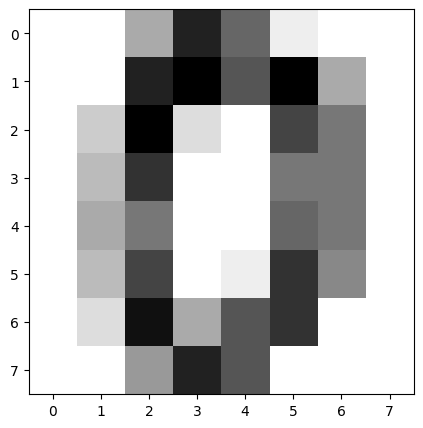

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
이 숫자는  0 입니다.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(ds.images[0], cmap=plt.cm.gray_r, interpolation='nearest')

plt.show()
print(ds.data[0])
print("이 숫자는 ", ds.target[0], "입니다.")

## 필기 숫자 인식
각 화소를 특징으로 간주하여 64차원 특징 벡터 사용

* SVM 분류기 모델을 사용하여 학습

In [ ]:
from sklearn import svm

clf = svm.SVC(gamma=0.1, C=10)
clf.fit(ds.data, ds.target)

SVC(C=10, gamma=0.1)

* 훈련 집합에 앞에 있는 샘플 3개를 새로운 샘플로 간주하고 인식 테스트를 진행

In [ ]:
new_ds = ds.data[0:3]
res = clf.predict(new_ds)

print("예측값은", res)
print("참값은", ds.target[0:3])

예측값은 [0 1 2]
참값은 [0 1 2]


* 훈련 집합을 테스트 집합으로 간주하여 인식한 정확률 측정

In [ ]:
correct = [i for i in range(len(res)) if res[i] == ds.target[i]]
accuracy = len(correct) / len(res)
print("화소 특징을 사용했을 때 정확률 = ", accuracy * 100, "%")

## 훈련/검증/테스트 집합으로 쪼개기

In [3]:
from sklearn import datasets
from sklearn import svm
from sklearn.model_selection import train_test_split
import numpy as np

데이터셋을 읽고 훈련 집합과 테스트 집합으로 분할

In [6]:
digit = datasets.load_digits()
x_train, x_test, y_train, y_test = train_test_split(digit.data, digit.target, train_size=0.6)

svm의 분류 모델 SVC를 학습

In [7]:
clf = svm.SVC(gamma=0.001)
clf.fit(x_train, y_train)

res = clf.predict(x_test)

혼동 행렬 작성

In [9]:
conf = np.zeros((10, 10))
for i in range(len(res)):
    conf[res[i]][y_test[i]] += 1

print(conf)

[[78.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 65.  0.  0.  0.  0.  0.  0.  3.  0.]
 [ 0.  0. 74.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 73.  0.  0.  0.  0.  0.  1.]
 [ 1.  0.  0.  0. 68.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0. 62.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. 72.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0. 71.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 74.  1.]
 [ 0.  0.  0.  0.  0.  1.  0.  1.  0. 71.]]


정확률 계산하기

In [10]:
no_correct = 0
for i in range(10):
    no_correct += conf[i][i]

accuracy = no_correct / len(res)

print("테스트 집합에 대한 정확률은", accuracy * 100, "%입니다.")

테스트 집합에 대한 정확률은 98.47009735744089 %입니다.


digit 데이터에 교차 검증 적용(모델 선택 제외)
cross_val_score 함수가 교차 검증 수행(cv=5 --> 5겹 교차 검증)

In [13]:
from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(clf, digit.data, digit.target, cv=5)

print(accuracies)
print("정확률(평균)=%0.3f, 표준편차=%0.3f"%(accuracies.mean()*100, accuracies.std()))

[0.975      0.95       0.98328691 0.99164345 0.96100279]
정확률(평균)=97.219, 표준편차=0.015
